<div align='center'>
    <h1>Tugas Pendahuluan Praktikum Dasar Kecerdasan Artifisial</h1>
    <h3>Modul 8: Implementasi Uniform Cost Search</h3>
</div>

## Petunjuk Umum

1. Jangan ubah struktur kode yang diberikan, cukup isi bagian yang kosong.
2. Jalankan setiap sel satu per satu untuk memastikan tidak ada error.
3. Gunakan modul praktikum atau dokumentasi NetworkX (https://networkx.org/documentation/stable) jika diperlukan.
4. Kerjakan soal yang ada secara berurutan, karena soal saling berkesinambungan.

In [1]:
print("Muhammad Alvin Faa'iz") # Tuliskan nama lengkap Anda
print("103012400229") # Tuliskan NIM Anda
print("IF-48-11") # Tuliskan kelas Anda
print("VVN") # Tuliskan kode asprak Anda

Muhammad Alvin Faa'iz
103012400229
IF-48-11
VVN


### Pengantar Uniform Cost Search (UCS)

Uniform Cost Search (UCS) adalah algoritma pencarian jalur optimal dalam graf yang
mencari jalur dengan cost terendah dari node awal (start) ke node tujuan (goal). UCS
meurpakan varian dari BFS, tetapi mempertimbangkan weight dari setiap edge dalam
graf. Algoritma ini berguna untuk menemukan jalur dengan total weight terendah.

In [2]:
import networkx as nx #import library networkx
import matplotlib.pyplot as plt #import library pyplot dari matplotlib

# Soal 1

Di negeri bernama **The Informatics Empire**, terdapat delapan kota besar yang saling terhubung, mulai dari pusat kekuasaan di Ditopolis hingga kota tambang emas di Omenberg. Kota-kota ini dibangun oleh para pendiri kerajaan seperti Anandia, Ariqton, Fahrya, Ecaville, Rezashire, Aliford, Omenberg, dan Yanton. Untuk memperkuat koneksi antar kota, **Sang Kaisar ingin menemukan jalur perjalanan paling efisien**.

Sebagai penasihat kerajaan, tugasmu adalah **membantu Sang Kaisar menemukan rute terbaik** dari Ditopolis ke Omenberg menggunakan algoritma Uniform Cost Search (UCS). Setiap jalur antar kota memiliki bobot yang mencerminkan jarak atau biaya perjalanan. Gunakan graf yang tersedia untuk memvisualisasikan rute dan temukan jalur dengan biaya paling rendah!

### Fungsi pendukung untuk mencetak graf 

#### **!! Tidak usah dimodifikasi !!**

In [3]:
# Posisi node untuk visualisasi graf
pos = {
    'Ditopolis': (0, 4),
    'Ariqton DC': (-2, 0),
    'Fahrya': (2, 0),
    'Ecaville': (-3, -4),
    'Rezashire': (-1, -4),
    'Aliford': (1, -4),
    'Omenberg': (3, -4),
    'Yanton': (1, -8)
}

In [4]:
# Fungsi pendukung untuk mencetak graf
def show_graph(G, pos=pos, title='Penambahan Nodes pada Graph') :
  # Membuat pos jika pos tidak diberikan
  if pos is None:
      pos = nx.spring_layout(G)
  
  # Fungsi untuk menggambar node
  nx.draw(
      G,                  # Graf NetworkX
      pos,                # Posisi node
      with_labels=True,   # Menampilkan nama node 
      node_color='red',   # Warna node
      node_size=3000,     # Ukuran node
      font_color="white", # Warna font label node
      font_weight="bold",
      font_size=7,
      width=5             # Ketebalan garis edge
  )

  # Mengambil label edge jika ada weight
  edge_labels = nx.get_edge_attributes(G, 'weight')  
  # Fungsi untuk menggambar node
  nx.draw_networkx_edge_labels(
      G,
      pos,
      edge_labels=edge_labels, # Data weight
      font_color='blue',       # Warna font label edge
      font_weight="bold",      # Berat font label edge
      font_size=16,            # Ukuran font label edge
  )

  plt.margins(0.2)  # Memberikan margin pada plot
  plt.title(title)  # Menampilkan judul graf jika diberikan
  plt.show()        # Menampilkan graf menggunakan matplotlib

**a.** Inisialisasi graf bernama `empire` menggunakan graf berarah untuk menunjukkan jalur utama antar kota di The Informatics Empire.

In [5]:
# Inisialisasi graf berarah
empire = nx.DiGraph()

**b.** Pada peta kerajaan, terdapat delapan kota besar yang menjadi pusat peradaban di The Informatics Empire. Nama-nama kota tersebut adalah:
`Ditopolis`, `Ariqton DC`, `Fahrya`, `Ecaville`, `Rezashire`, `Aliford`, `Omenberg`, dan `Yanton`.
Tambahkan nama-nama kota tersebut ke dalam graph `empire`.

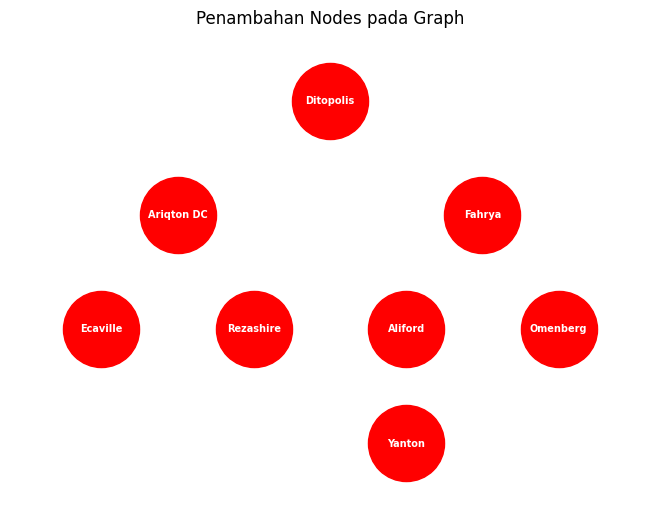

In [6]:
# Tambahkan node
cities = ["Ditopolis", "Ariqton DC", "Fahrya", "Ecaville", "Rezashire", "Aliford", "Omenberg", "Yanton"]
empire.add_nodes_from(cities)

# Tampilkan graph
show_graph(empire, pos=pos)

Contoh *output*:

![Contoh output 1](./asset/1_tambah_node.png)

**c.** Berikut adalah jarak dari setiap rute yang terdapat pada peta The Informatics Empire:

* `Ditopolis` ke `Ariqton DC` memiliki rute sepanjang 3 km.
* `Ditopolis` ke `Fahrya` memiliki rute sepanjang 3 km.
* `Ariqton DC` ke `Ecaville` memiliki rute sepanjang 2 km.
* `Ariqton DC` ke `Rezashire` memiliki rute sepanjang 2 km.
* `Fahrya` ke `Aliford` memiliki rute sepanjang 2 km.
* `Fahrya` ke `Omenberg` memiliki rute sepanjang 2 km.
* `Aliford` ke `Yanton` memiliki rute sepanjang 3 km.

Tambahkan data rute tersebut ke dalam graph `empire`.

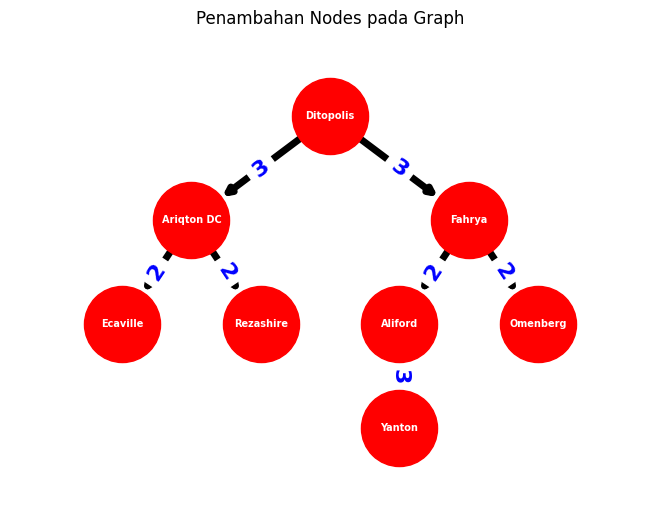

In [7]:
# Tambahkan edge dan bobotnya
edges = [
    ("Ditopolis", "Ariqton DC", 3),
    ("Ditopolis","Fahrya",3 ),
    ("Ariqton DC", "Ecaville", 2),
    ("Ariqton DC", "Rezashire", 2),
    ("Fahrya",  "Aliford",  2),
    ("Fahrya", "Omenberg", 2),
    ("Aliford",  "Yanton",  3)
]

empire.add_weighted_edges_from(edges)

# Tampilkan graf
show_graph(empire, pos=pos)

Contoh *output*:

![Contoh output 2](./asset/2_tambah_edge.png)

**d.** Buat sebuah program yang memanfaatkan graph `empire` untuk mencetak setiap kota dan kota-kota lainnya yang terhubung dengan kota tersebut.

In [8]:
print("Koneksi setiap kota")

# Iterasi untuk setiap node (markas) yang ada di graf `peta_rahasia`
for node in empire.nodes() :
    # Ambil semua node yang terhubung dengan node saat ini
    children = list(empire.neighbors(node))

    # Jika markas terhubung dengan markas lainnya, tampilkan daftarnya
    if len(children) > 0 :
        # Tampilkan nama markas beserta daftar terhubung ke markas lainnya
        print(node, "terhubung dengan: ", children)

Koneksi setiap kota
Ditopolis terhubung dengan:  ['Ariqton DC', 'Fahrya']
Ariqton DC terhubung dengan:  ['Ecaville', 'Rezashire']
Fahrya terhubung dengan:  ['Aliford', 'Omenberg']
Aliford terhubung dengan:  ['Yanton']


Contoh *output*:

`Koneksi setiap kota` <br>
`- Ditopolis terhubung dengan: ['Ariqton DC', 'Fahrya']`<br>
`- Ariqton DC terhubung dengan: ['Ecaville', 'Rezashire']`<br>
`- Fahrya terhubung dengan: ['Aliford', 'Omenberg']`<br>
`- Aliford terhubung dengan: ['Yanton']`

**e.** Pada potongan kode di bawah, buat fungsi `heuristable(a, b)`. Karena algoritma UCS tidak menggunakan nilai heuristik, cukup kembalikan nilai 0.

In [9]:
def heuristable(a, b) :
    return 0 # Kembalikan nilai 0

**f.** Pada potongan kode di bawah, buat kode untuk menemukan rute terpendek antara dua kota dengan mempertimbangkan jarak total antara kota awal dan kota tujuan yang dimasukkan oleh pengguna.

Gunakan algoritma Uniform Cost Search (UCS) yang diimplementasikan menggunakan fungsi astar_path() pada NetworkX dengan nilai heuristik 0 yang sudah didefinisikan pada fungsi `heuristable(a, b)`.

Kemudian tampilkan rute terpendek yang sudah dicari antara titik awal dan titik tujuan yang sudah dimasukkan oleh user, serta tampilkan juga total jarak yang ditempuh dari titik awal ke titik tujuan tersebut.

In [17]:
# Minta input dari pengguna untuk titik awal dan titik tujuan
start_node = input("Titik awal:")
end_node = input("Titik tujuan:")

# Mencari titik yang dikunjungi dari titik awal ke titik tujuan
path = nx.astar_path(
    empire, start_node, end_node, heuristic=heuristable, weight="weight"
)

# Menghitung jarak dari titik awal ke titik tujuan
path_length = nx.astar_path_length(
    empire, start_node, end_node, heuristic=heuristable,weight="weight"
)

# Cetak hasil

print("Titik yang dikunjungi dari", start_node, "ke", end_node, ":",path)
print("Jarak terpendek dari", start_node, "ke", end_node, ":",path_length, "km")

Titik awal: Ditopolis
Titik tujuan: Omenberg


Titik yang dikunjungi dari Ditopolis ke Omenberg : ['Ditopolis', 'Fahrya', 'Omenberg']
Jarak terpendek dari Ditopolis ke Omenberg : 5 km


Contoh *output*:

`Titik yang dikunjungi dari Ditopolis ke Omenberg: ['Ditopolis', 'Fahrya', 'Omenberg']`<br>
`Jarak terpendek dari Ditopolis ke Omenberg: 5 km`